In [13]:
# ─── SOURCE  (Starfire nGen-310 — CERN RP Safety File EDMS 3409579 §2.1) ─────
E0_MEV           = 2.45    # [MeV]  DD neutron energy (monoenergetic)
E0_SPREAD_KEV    = 50.0    # [keV]  ±1σ energy spread (doc: ±50 keV)

# ─── B-HDPE SHIELD  (doc §2.2) ───────────────────────────────────────────────
PE_THICKNESS_CM  = 15.0   # [cm]   lateral wall thickness (doc: 15 cm side walls)
BHDPE_DENSITY    = 1.0    # [g/cm³]  (doc: 1.0 g/cm³)
BORON_MASS_FRAC  = 0.05   # boron mass fraction (doc: 5% by weight, natural boron)
B10_ENRICHMENT   = 0.199  # B-10 atom fraction (doc: natural boron)

# Reference values from doc §2.2 — for cross-checks against MC output:
MFP_DOC_CM       = 3.42   # [cm]   mean free path at 2.45 MeV
MACRO_XS_DOC     = 0.292  # [cm⁻¹] macroscopic total cross-section at 2.45 MeV

# lib_neutrons.get_mean_free_path() is hardcoded to rho = 0.95 g/cm³.
# Scale its output to match the actual B-HDPE density (number densities ∝ rho).
MFP_DENSITY_CORRECTION = 0.95 / BHDPE_DENSITY   # 0.95 for density 1.0

# B-10 capture cross-section (1/v law, ENDF/B-VIII.0)
SIGMA_B10_THERMAL_BARNS = 3840.0  # barns at E_THERMAL_EV
E_THERMAL_EV            = 0.0253  # eV (room temperature)

# ─── MONTE CARLO ─────────────────────────────────────────────────────────────
N_NEUTRONS       = 100_000 # number of neutrons to simulate
ABSORPTION_PROB  = 0.02   # H-capture probability per scattering collision
ENERGY_LOSS_FRAC = 0.5    # avg fractional energy loss per H-collision

# ─── PLOT ────────────────────────────────────────────────────────────────────
E_MIN_EV         = 0.01   # [eV]  lower axis limit
E_MAX_EV         = 4e6    # [eV]  upper axis limit


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from lib_neutrons import calculate_moderated_spectrum, calculate_flux_fractions, get_mean_free_path

N_A   = 6.022e23
M_B10 = 10.0  # g/mol

# B-10 number density in B-HDPE
n_B10 = (BHDPE_DENSITY * BORON_MASS_FRAC * B10_ENRICHMENT / M_B10) * N_A  # cm⁻³

# Cross-check: MFP at 2.45 MeV after density correction vs. doc reference
mfp_lib  = get_mean_free_path(E0_MEV * 1e6) * MFP_DENSITY_CORRECTION
print(f"B-10 number density          : {n_B10:.3e} cm⁻³")
print(f"MFP at 2.45 MeV (lib×corr)  : {mfp_lib:.2f} cm  (doc: {MFP_DOC_CM} cm)")
print(f"Σ   at 2.45 MeV (lib×corr)  : {1/mfp_lib:.3f} cm⁻¹  (doc: {MACRO_XS_DOC} cm⁻¹)")

# ── Analytical moderation (plain PE model — boron does not scatter) ──────────
E0_kev               = E0_MEV * 1e3
initial_energies_kev = np.logspace(-3, 4, 2000)
sigma_kev            = E0_SPREAD_KEV                    # ±50 keV from doc
initial_spectrum     = np.exp(-0.5 * ((initial_energies_kev - E0_kev) / sigma_kev) ** 2)

mod_E_kev, mod_spectrum = calculate_moderated_spectrum(
    initial_energies_kev, initial_spectrum,
    hdpe_thickness_cm=PE_THICKNESS_CM)

# ── Apply B-10 capture suppression (approximate post-correction) ─────────────
mod_E_eV     = mod_E_kev * 1e3
sigma_B10    = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(mod_E_eV, E_THERMAL_EV))
Sigma_B10    = n_B10 * sigma_B10 * 1e-24
B10_survival = np.exp(-Sigma_B10 * PE_THICKNESS_CM)
mod_spectrum_bhdpe = mod_spectrum * B10_survival

fracs_pe    = calculate_flux_fractions(mod_E_kev, mod_spectrum)
fracs_bhdpe = calculate_flux_fractions(mod_E_kev, mod_spectrum_bhdpe)

print(f"\nAnalytical — plain PE vs B-HDPE ({BORON_MASS_FRAC*100:.0f}% B, natural)")
print(f"{'Region':<22} {'Plain PE':>10} {'B-HDPE':>10}")
print("-" * 44)
for key in ('cold', 'thermal', 'epithermal', 'fast'):
    print(f"  {key:<20} {fracs_pe[key]*100:>9.1f}% {fracs_bhdpe[key]*100:>9.1f}%")


B-10 number density          : 5.992e+20 cm⁻³
MFP at 2.45 MeV (lib×corr)  : 3.83 cm  (doc: 3.42 cm)
Σ   at 2.45 MeV (lib×corr)  : 0.261 cm⁻¹  (doc: 0.292 cm⁻¹)

Analytical — plain PE vs B-HDPE (5% B, natural)
Region                   Plain PE     B-HDPE
--------------------------------------------
  cold                       4.1%       0.0%
  thermal                   95.7%     100.0%
  epithermal                 0.0%       0.0%
  fast                       0.0%       0.0%


In [15]:
import time as time_module
from lib_neutrons import get_mean_free_path, calculate_energy_fractions

E0_eV = E0_MEV * 1e6

E_final_eV   = np.zeros(N_NEUTRONS)
n_collisions = np.zeros(N_NEUTRONS, dtype=int)
absorbed     = np.zeros(N_NEUTRONS, dtype=bool)
abs_by_boron = np.zeros(N_NEUTRONS, dtype=bool)

print(f"MC: {N_NEUTRONS:,} neutrons at {E0_MEV} MeV through {PE_THICKNESS_CM} cm B-HDPE")
print(f"    ρ = {BHDPE_DENSITY} g/cm³, MFP correction = {MFP_DENSITY_CORRECTION:.3f}")
print(f"    boron {BORON_MASS_FRAC*100:.0f}% wt, B-10 frac {B10_ENRICHMENT:.3f}, "
      f"n_B10 = {n_B10:.2e} cm⁻³")
t0 = time_module.time()

for i in range(N_NEUTRONS):
    E      = E0_eV
    pos    = 0.0
    n_coll = 0
    dead   = False
    boron  = False

    while pos < PE_THICKNESS_CM:
        # Scattering MFP from ENDF H+C, corrected to actual B-HDPE density
        mfp_scatter   = get_mean_free_path(E) * MFP_DENSITY_CORRECTION
        Sigma_scatter  = 1.0 / mfp_scatter

        # B-10 macroscopic capture cross-section: σ ∝ 1/v
        sigma_b10 = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / max(E, E_THERMAL_EV))
        Sigma_b10 = n_B10 * sigma_b10 * 1e-24   # cm⁻¹

        # Total cross-section → combined mean free path
        Sigma_total = Sigma_scatter + Sigma_b10
        mfp_total   = 1.0 / Sigma_total

        step = -mfp_total * np.log(np.random.random())

        if pos + step >= PE_THICKNESS_CM:    # exits without further interaction
            pos = PE_THICKNESS_CM
            break

        pos    += step
        n_coll += 1

        # Interaction type sampled proportional to cross-sections
        if np.random.random() * Sigma_total < Sigma_b10:   # B-10 capture
            dead  = True
            boron = True
            break
        else:                                               # H or C scatter
            if np.random.random() < ABSORPTION_PROB:       # rare H capture
                dead = True
                break
            loss_frac = np.random.random() * ENERGY_LOSS_FRAC * 2
            E *= max(1.0 - loss_frac, 0.0)
            E  = max(E, 0.025)              # floor at thermal

    E_final_eV[i]   = E
    n_collisions[i] = n_coll
    absorbed[i]     = dead
    abs_by_boron[i] = boron

    if (i + 1) % 25_000 == 0:
        print(f"  {i+1:,}/{N_NEUTRONS:,} ({100*(i+1)/N_NEUTRONS:.0f}%)")

elapsed   = time_module.time() - t0
survived  = ~absorbed
n_surv    = np.sum(survived)
n_abs_B10 = np.sum(abs_by_boron)
n_abs_H   = np.sum(absorbed & ~abs_by_boron)

fracs_mc = calculate_energy_fractions(E_final_eV[survived])
print(f"\n✓ Done in {elapsed:.1f} s  ({int(N_NEUTRONS/elapsed):,} n/s)")
print(f"  Survived    : {n_surv:,} ({100*n_surv/N_NEUTRONS:.1f}%)")
print(f"  B-10 capture: {n_abs_B10:,} ({100*n_abs_B10/N_NEUTRONS:.1f}%)")
print(f"  H capture   : {n_abs_H:,} ({100*n_abs_H/N_NEUTRONS:.1f}%)")
print(f"  Mean coll   : {np.mean(n_collisions[survived]):.1f}  "
      f"(doc: ~{PE_THICKNESS_CM/MFP_DOC_CM:.1f} MFPs = {PE_THICKNESS_CM/MFP_DOC_CM:.2f})")
print(f"  Thermal     : {fracs_mc['thermal']*100:.1f}%")
print(f"  Epithermal  : {fracs_mc['epithermal']*100:.1f}%")
print(f"  Fast        : {fracs_mc['fast']*100:.1f}%")
print(f"  Mean E      : {fracs_mc['mean_eV']:.2f} eV   Median E: {fracs_mc['median_eV']:.2f} eV")


MC: 100,000 neutrons at 2.45 MeV through 15.0 cm B-HDPE
    ρ = 1.0 g/cm³, MFP correction = 0.950
    boron 5% wt, B-10 frac 0.199, n_B10 = 5.99e+20 cm⁻³
  25,000/100,000 (25%)
  50,000/100,000 (50%)
  75,000/100,000 (75%)
  100,000/100,000 (100%)

✓ Done in 66.4 s  (1,505 n/s)
  Survived    : 62,173 (62.2%)
  B-10 capture: 22,497 (22.5%)
  H capture   : 15,330 (15.3%)
  Mean coll   : 6.6  (doc: ~4.4 MFPs = 4.39)
  Thermal     : 22.9%
  Epithermal  : 53.0%
  Fast        : 23.5%
  Mean E      : 379876.01 eV   Median E: 33721.22 eV


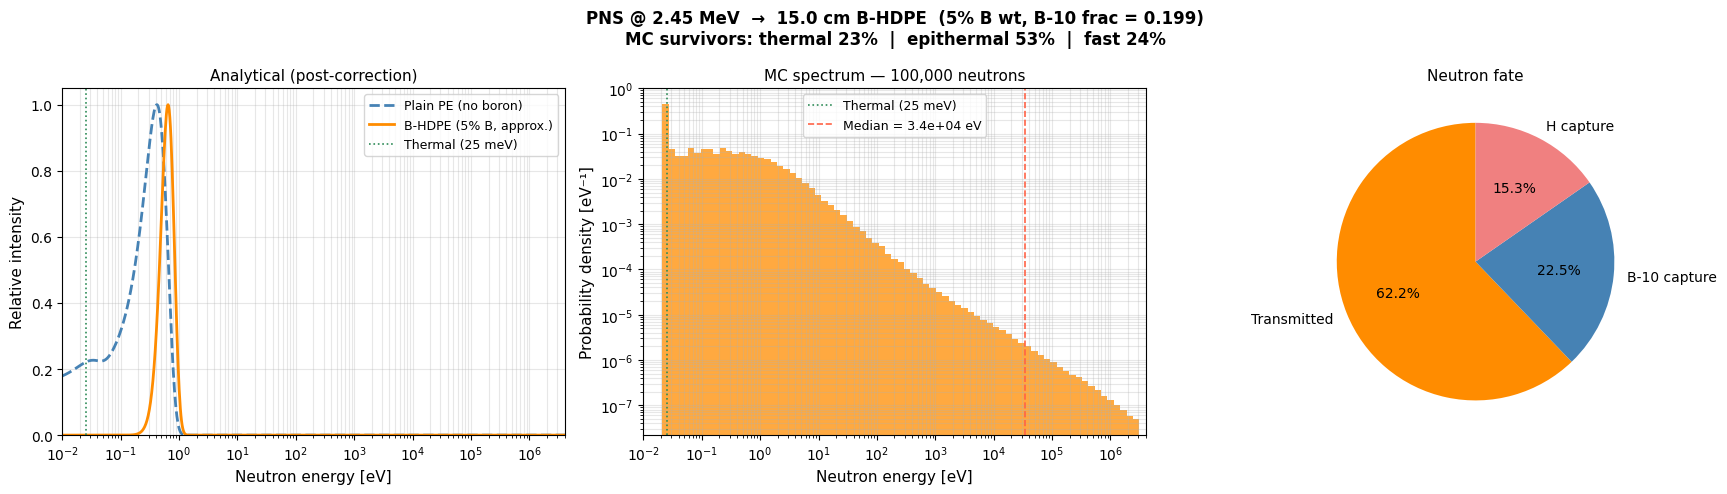

Saved → pns_bhdpe_spectrum.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: analytical — plain PE vs B-HDPE ────────────────────────────────────
ax = axes[0]
norm_pe    = np.max(mod_spectrum)      if np.max(mod_spectrum)      > 0 else 1
norm_bhdpe = np.max(mod_spectrum_bhdpe) if np.max(mod_spectrum_bhdpe) > 0 else 1
ax.semilogx(mod_E_eV, mod_spectrum       / norm_pe,    color='steelblue', lw=2,
            ls='--', label='Plain PE (no boron)')
ax.semilogx(mod_E_eV, mod_spectrum_bhdpe / norm_bhdpe, color='darkorange', lw=2,
            label=f'B-HDPE ({BORON_MASS_FRAC*100:.0f}% B, approx.)')
ax.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax.set_xlabel('Neutron energy [eV]', fontsize=11)
ax.set_ylabel('Relative intensity', fontsize=11)
ax.set_title('Analytical (post-correction)', fontsize=11)
ax.set_xlim(E_MIN_EV, E_MAX_EV)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# ── Centre: MC energy spectrum ────────────────────────────────────────────────
ax2 = axes[1]
bins = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 80)
ax2.hist(E_final_eV[survived], bins=bins, color='darkorange', alpha=0.75,
         edgecolor='none', density=True)
ax2.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax2.axvline(fracs_mc['median_eV'], color='tomato', ls='--', lw=1.2,
            label=f"Median = {fracs_mc['median_eV']:.2g} eV")
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Neutron energy [eV]', fontsize=11)
ax2.set_ylabel('Probability density [eV⁻¹]', fontsize=11)
ax2.set_title(f'MC spectrum — {N_NEUTRONS:,} neutrons', fontsize=11)
ax2.set_xlim(E_MIN_EV, E_MAX_EV)
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

# ── Right: fate breakdown (pie) ───────────────────────────────────────────────
ax3 = axes[2]
frac_surv  = n_surv / N_NEUTRONS
frac_b10   = n_abs_B10 / N_NEUTRONS
frac_h     = n_abs_H / N_NEUTRONS
wedges, texts, autotexts = ax3.pie(
    [frac_surv, frac_b10, frac_h],
    labels=['Transmitted', 'B-10 capture', 'H capture'],
    colors=['darkorange', 'steelblue', 'lightcoral'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10})
ax3.set_title('Neutron fate', fontsize=11)

fig.suptitle(
    f'PNS @ {E0_MEV} MeV  →  {PE_THICKNESS_CM} cm B-HDPE  '
    f'({BORON_MASS_FRAC*100:.0f}% B wt, B-10 frac = {B10_ENRICHMENT:.3f})\n'
    f'MC survivors: thermal {fracs_mc["thermal"]*100:.0f}%  |  '
    f'epithermal {fracs_mc["epithermal"]*100:.0f}%  |  '
    f'fast {fracs_mc["fast"]*100:.0f}%',
    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('pns_bhdpe_spectrum.png', dpi=120)
plt.show()
print("Saved → pns_bhdpe_spectrum.png")


In [17]:
# ─── Parameters ──────────────────────────────────────────────────────────────
EMISSION_RATE      = 1e7   # [n/s]  source rate (doc max: 1e7 n/s)
DISTANCE_CM        = 100.0 # [cm]   distance from source centre to surface
SURFACE_AREA_CM2   = 9.0   # [cm²]  detector surface (e.g. 3×3 cm tile)

# ─── Flux calculation (isotropic point source) ────────────────────────────────
# The MC gives the fraction of neutrons that survive the B-HDPE shield.
# Beyond the shield the field is treated as isotropic → 1/r² dilution only.
transmission = n_surv / N_NEUTRONS                         # shield survival fraction

flux_cm2_s = EMISSION_RATE * transmission / (4 * np.pi * DISTANCE_CM**2)  # [n/cm²/s]
rate_surface = flux_cm2_s * SURFACE_AREA_CM2               # [n/s] through the surface

print(f"Source emission rate      : {EMISSION_RATE:.1e} n/s")
print(f"B-HDPE transmission (MC)  : {transmission*100:.2f}%  "
      f"({n_surv:,} / {N_NEUTRONS:,} neutrons)")
print(f"Distance from source      : {DISTANCE_CM:.1f} cm  ({DISTANCE_CM/100:.2f} m)")
print(f"Surface area              : {SURFACE_AREA_CM2:.1f} cm²")
print()
print(f"Flux at surface           : {flux_cm2_s:.3e} n/cm²/s")
print(f"Rate through surface      : {rate_surface:.3e} n/s")
print(f"                          = {rate_surface*3600:.3e} n/hr")


Source emission rate      : 1.0e+07 n/s
B-HDPE transmission (MC)  : 62.17%  (62,173 / 100,000 neutrons)
Distance from source      : 100.0 cm  (1.00 m)
Surface area              : 9.0 cm²

Flux at surface           : 4.948e+01 n/cm²/s
Rate through surface      : 4.453e+02 n/s
                          = 1.603e+06 n/hr


In [18]:
# ─── Scintillator parameters ─────────────────────────────────────────────────
SCINT_THICKNESS_CM   = 1.0    # [cm]   sample thickness
SCINT_DENSITY        = 1.05   # [g/cm³] typical plastic scintillator (PVT/PS)
SCINT_BORON_FRAC     = 0.02   # boron mass fraction (2% doping)
SCINT_B10_ENRICHMENT = 0.199  # B-10 atom fraction (natural boron)

# ─── B-10 number density in scintillator ─────────────────────────────────────
N_A_loc   = 6.022e23
M_B10_loc = 10.0
n_B10_scint = (SCINT_DENSITY * SCINT_BORON_FRAC * SCINT_B10_ENRICHMENT / M_B10_loc) * N_A_loc

# ─── Energy-resolved interaction probability (using MC spectrum) ──────────────
# For each surviving neutron from the shield MC, compute the probability that
# it undergoes a B-10 capture in 1 cm of scintillator.
# σ_B10(E) follows 1/v → σ = σ_thermal × √(E_thermal / E)
E_surv = E_final_eV[survived]   # energy array for transmitted neutrons

sigma_b10_scint = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(E_surv, E_THERMAL_EV))
Sigma_b10_scint = n_B10_scint * sigma_b10_scint * 1e-24    # macroscopic [cm⁻¹]
p_interact      = 1.0 - np.exp(-Sigma_b10_scint * SCINT_THICKNESS_CM)

mean_p   = np.mean(p_interact)
median_p = np.median(p_interact)

# ─── Event rate ───────────────────────────────────────────────────────────────
# rate_surface neutrons/s enter the surface; mean_p of them interact via B-10
event_rate = rate_surface * mean_p

print(f"Scintillator: {SCINT_THICKNESS_CM} cm thick, "
      f"ρ = {SCINT_DENSITY} g/cm³, "
      f"B = {SCINT_BORON_FRAC*100:.0f}% wt (natural)")
print(f"n_B10 in scintillator     : {n_B10_scint:.3e} cm⁻³")
print()
print(f"B-10 interaction prob (mean)  : {mean_p*100:.3f}%  (averaged over MC spectrum)")
print(f"B-10 interaction prob (median): {median_p*100:.3f}%")
print()
print(f"Neutron rate through surface  : {rate_surface:.3e} n/s")
print(f"B-10 event rate in scintillator: {event_rate:.3e} events/s")
print(f"                               = {event_rate*3600:.3e} events/hr")
print(f"                               = {event_rate*3600*24:.3e} events/day")

# ─── Per-energy-group breakdown ───────────────────────────────────────────────
print()
print("Interaction prob by energy group (from MC spectrum):")
groups = [
    ("thermal   (<1 eV)",       E_surv <  1.0),
    ("epithermal (1 eV–100 keV)", (E_surv >= 1.0) & (E_surv < 1e5)),
    ("fast      (>100 keV)",    E_surv >= 1e5),
]
for label, mask in groups:
    if np.any(mask):
        p_grp = np.mean(p_interact[mask])
        frac  = np.sum(mask) / len(E_surv)
        print(f"  {label}: p = {p_grp*100:.3f}%  ({frac*100:.1f}% of survivors)")
    else:
        print(f"  {label}: no neutrons in this group")


Scintillator: 1.0 cm thick, ρ = 1.05 g/cm³, B = 2% wt (natural)
n_B10 in scintillator     : 2.517e+20 cm⁻³

B-10 interaction prob (mean)  : 2.258%  (averaged over MC spectrum)
B-10 interaction prob (median): 0.084%

Neutron rate through surface  : 4.453e+02 n/s
B-10 event rate in scintillator: 1.005e+01 events/s
                               = 3.620e+04 events/hr
                               = 8.687e+05 events/day

Interaction prob by energy group (from MC spectrum):
  thermal   (<1 eV): p = 26.064%  (3.9% of survivors)
  epithermal (1 eV–100 keV): p = 2.250%  (55.1% of survivors)
  fast      (>100 keV): p = 0.022%  (41.0% of survivors)


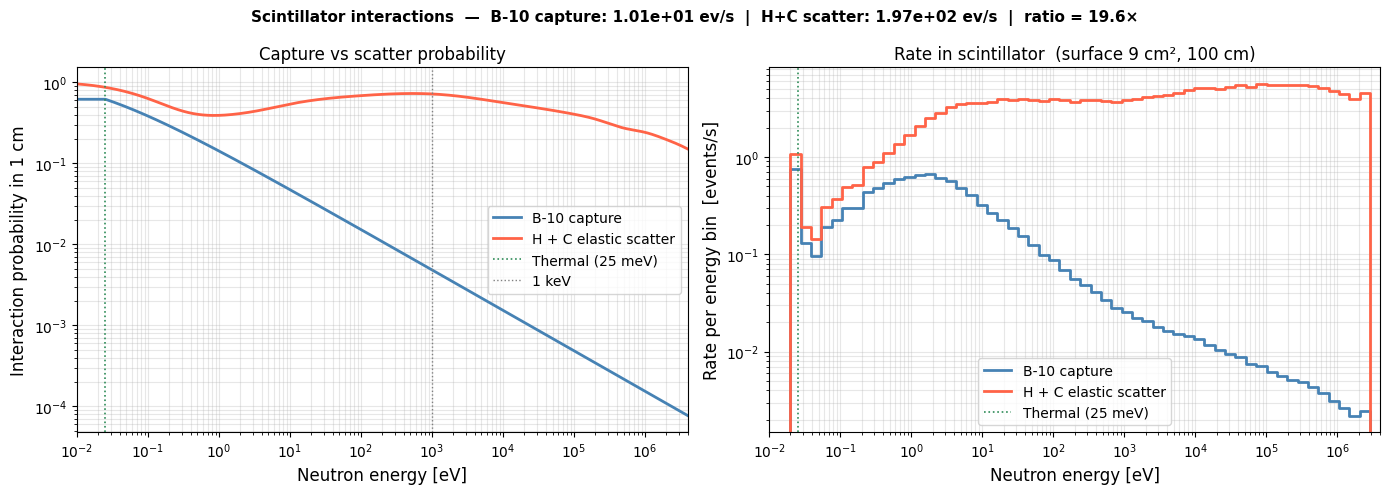

Total B-10 capture rate : 1.005e+01 events/s
Total H+C scatter rate  : 1.966e+02 events/s
Scatter / capture ratio : 19.6


In [19]:
from lib_neutrons import get_endf_cross_sections

# ─── Scintillator composition (PVT ≈ C₉H₁₀, 2% B doping) ────────────────────
# Remaining 98% of mass is the polymer base.  PVT: ~8.47% H, ~91.53% C by mass.
SCINT_H_FRAC = (1.0 - SCINT_BORON_FRAC) * (10 / 118)    # ≈ 0.0830
SCINT_C_FRAC = (1.0 - SCINT_BORON_FRAC) * (108 / 118)   # ≈ 0.8967

n_H_scint = (SCINT_DENSITY * SCINT_H_FRAC / 1.0)  * N_A_loc   # cm⁻³
n_C_scint = (SCINT_DENSITY * SCINT_C_FRAC / 12.0) * N_A_loc   # cm⁻³

# ─── Energy grid for smooth probability curves ────────────────────────────────
E_grid = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 500)

sigma_H_grid, sigma_C_grid = get_endf_cross_sections(E_grid)
Sigma_scatter_grid = (n_H_scint * sigma_H_grid + n_C_scint * sigma_C_grid) * 1e-24  # cm⁻¹

sigma_b10_grid = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(E_grid, E_THERMAL_EV))
Sigma_b10_grid = n_B10_scint * sigma_b10_grid * 1e-24   # cm⁻¹

p_scatter_grid = 1.0 - np.exp(-Sigma_scatter_grid * SCINT_THICKNESS_CM)
p_capture_grid = 1.0 - np.exp(-Sigma_b10_grid     * SCINT_THICKNESS_CM)

# ─── Rate per energy bin (weighted by MC spectrum) ────────────────────────────
bins = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 60)
bin_centres = np.sqrt(bins[:-1] * bins[1:])   # geometric mean

# p_capture and p_scatter per surviving MC neutron
sigma_H_mc, sigma_C_mc = get_endf_cross_sections(E_surv)
Sigma_scatter_mc = (n_H_scint * sigma_H_mc + n_C_scint * sigma_C_mc) * 1e-24
p_scatter_mc = 1.0 - np.exp(-Sigma_scatter_mc * SCINT_THICKNESS_CM)
# p_interact (B-10 capture) already computed in previous cell as p_interact

bin_idx = np.digitize(E_surv, bins) - 1   # which bin each neutron falls into
n_bins  = len(bin_centres)

rate_capture_bin  = np.zeros(n_bins)
rate_scatter_bin  = np.zeros(n_bins)

for k in range(n_bins):
    mask_k = bin_idx == k
    if np.any(mask_k):
        # fraction of surface flux in this bin × respective probability → events/s
        flux_frac = np.sum(mask_k) / len(E_surv)
        rate_capture_bin[k] = rate_surface * flux_frac * np.mean(p_interact[mask_k])
        rate_scatter_bin[k] = rate_surface * flux_frac * np.mean(p_scatter_mc[mask_k])

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: interaction probability vs energy
ax1.loglog(E_grid, p_capture_grid, color='steelblue', lw=2,
           label='B-10 capture')
ax1.loglog(E_grid, p_scatter_grid, color='tomato',    lw=2,
           label='H + C elastic scatter')
ax1.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax1.axvline(1e3,    color='gray',     ls=':', lw=1.0, label='1 keV')
ax1.set_xlabel('Neutron energy [eV]', fontsize=12)
ax1.set_ylabel(f'Interaction probability in {SCINT_THICKNESS_CM:.0f} cm', fontsize=12)
ax1.set_title('Capture vs scatter probability', fontsize=12)
ax1.set_xlim(E_MIN_EV, E_MAX_EV)
ax1.legend(fontsize=10)
ax1.grid(True, which='both', alpha=0.3)

# Right: rate per energy bin
ax2.step(bin_centres, rate_capture_bin, where='mid', color='steelblue', lw=2,
         label='B-10 capture')
ax2.step(bin_centres, rate_scatter_bin, where='mid', color='tomato',    lw=2,
         label='H + C elastic scatter')
ax2.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Neutron energy [eV]', fontsize=12)
ax2.set_ylabel('Rate per energy bin  [events/s]', fontsize=12)
ax2.set_title(f'Rate in scintillator  (surface {SURFACE_AREA_CM2:.0f} cm², {DISTANCE_CM:.0f} cm)', fontsize=12)
ax2.set_xlim(E_MIN_EV, E_MAX_EV)
ax2.legend(fontsize=10)
ax2.grid(True, which='both', alpha=0.3)

total_capture_rate  = np.sum(rate_capture_bin)
total_scatter_rate  = np.sum(rate_scatter_bin)
fig.suptitle(
    f'Scintillator interactions  —  '
    f'B-10 capture: {total_capture_rate:.2e} ev/s  |  '
    f'H+C scatter: {total_scatter_rate:.2e} ev/s  |  '
    f'ratio = {total_scatter_rate/total_capture_rate:.1f}×',
    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('scint_capture_vs_scatter.png', dpi=120)
plt.show()

print(f"Total B-10 capture rate : {total_capture_rate:.3e} events/s")
print(f"Total H+C scatter rate  : {total_scatter_rate:.3e} events/s")
print(f"Scatter / capture ratio : {total_scatter_rate/total_capture_rate:.1f}")


Reference ToF values at 100 cm:
  2.45 MeV (source)     : 46.2 ns  =  0.046 μs
  100 keV               : 228.6 ns  =  0.229 μs
  1 eV                  : 72296.4 ns  =  72.296 μs
  25 meV (thermal)      : 454523.7 ns  =  454.524 μs


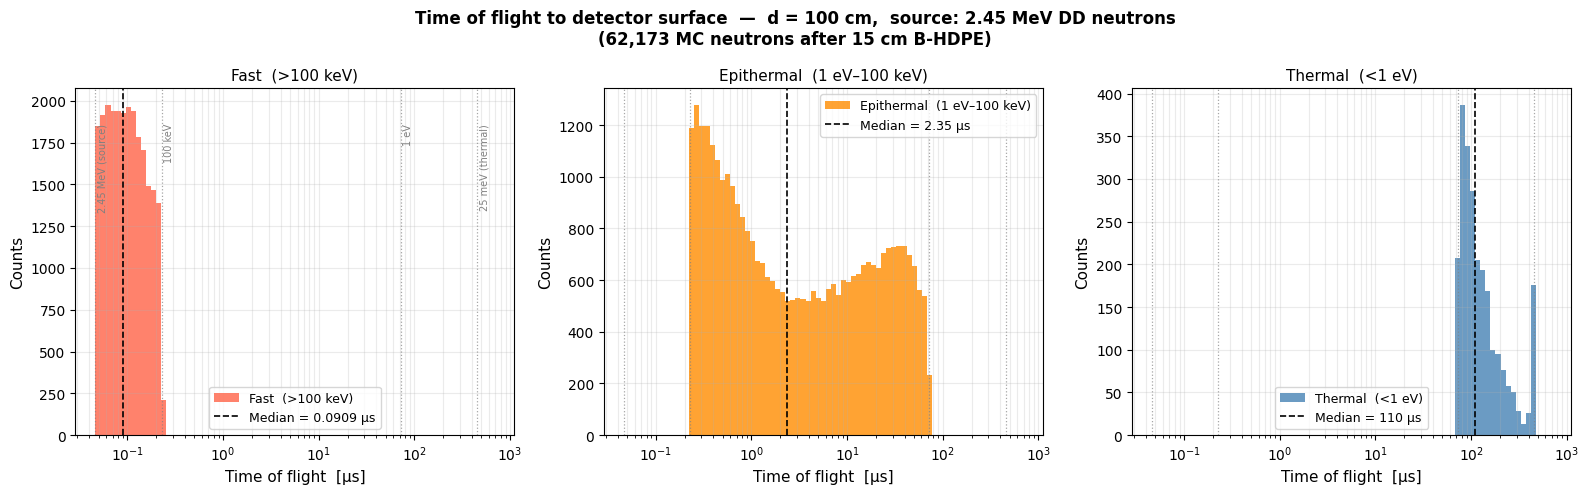

Saved → pns_tof_histograms.png


In [20]:
from lib_neutrons import tof_constant_energy

# ─── ToF at detector surface (free-flight from source, distance = DISTANCE_CM) ─
# This is a lower bound on the true ToF (ignores time spent bouncing in shield),
# but the shield is only 15 cm vs 100 cm total, so the correction is small for
# fast neutrons and negligible for thermal ones (slow inside too, but isotropic).
tof_us = tof_constant_energy(E_surv, DISTANCE_CM) * 1e6   # convert s → μs

# ─── Energy group masks ───────────────────────────────────────────────────────
mask_thermal    = E_surv <  1.0
mask_epithermal = (E_surv >= 1.0) & (E_surv < 1e5)
mask_fast       = E_surv >= 1e5

# ─── Reference ToF values ────────────────────────────────────────────────────
tof_refs = {
    '2.45 MeV (source)': tof_constant_energy(E0_MEV * 1e6, DISTANCE_CM) * 1e6,
    '100 keV':           tof_constant_energy(1e5,           DISTANCE_CM) * 1e6,
    '1 eV':              tof_constant_energy(1.0,           DISTANCE_CM) * 1e6,
    '25 meV (thermal)':  tof_constant_energy(E_THERMAL_EV,  DISTANCE_CM) * 1e6,
}
print(f"Reference ToF values at {DISTANCE_CM:.0f} cm:")
for label, t in tof_refs.items():
    print(f"  {label:<22}: {t*1e3:.1f} ns  =  {t:.3f} μs")

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

tof_bins = np.logspace(
    np.log10(max(tof_us.min(), 1e-3)),
    np.log10(tof_us.max() * 1.5),
    80)

group_defs = [
    (mask_fast,        'Fast  (>100 keV)',       'tomato',     axes[0]),
    (mask_epithermal,  'Epithermal  (1 eV–100 keV)', 'darkorange', axes[1]),
    (mask_thermal,     'Thermal  (<1 eV)',        'steelblue',  axes[2]),
]

for mask, label, color, ax in group_defs:
    if np.any(mask):
        ax.hist(tof_us[mask], bins=tof_bins, color=color, alpha=0.8,
                edgecolor='none', label=label)
        ax.axvline(np.median(tof_us[mask]), color='black', ls='--', lw=1.2,
                   label=f'Median = {np.median(tof_us[mask]):.3g} μs')

    # shared reference lines
    for ref_label, t_ref in tof_refs.items():
        ax.axvline(t_ref, color='gray', ls=':', lw=0.9, alpha=0.7)

    ax.set_xscale('log')
    ax.set_xlabel('Time of flight  [μs]', fontsize=11)
    ax.set_ylabel('Counts', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.25)

# Annotate reference lines on the first panel
for ref_label, t_ref in tof_refs.items():
    axes[0].text(t_ref * 1.05, axes[0].get_ylim()[1] * 0.9,
                 ref_label, rotation=90, fontsize=7, va='top', color='gray')

fig.suptitle(
    f'Time of flight to detector surface  —  '
    f'd = {DISTANCE_CM:.0f} cm,  source: {E0_MEV} MeV DD neutrons\n'
    f'({n_surv:,} MC neutrons after {PE_THICKNESS_CM:.0f} cm B-HDPE)',
    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('pns_tof_histograms.png', dpi=120)
plt.show()
print("Saved → pns_tof_histograms.png")


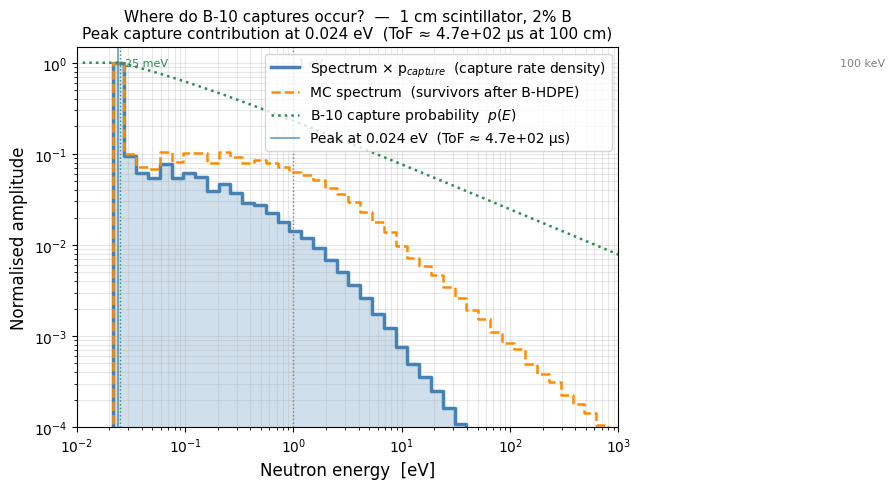

Peak capture contribution at  : 0.024 eV
Corresponding ToF at 100 cm      : 466 μs
B-10 capture prob at peak     : 61.95%


In [ ]:
# ─── Spectrum × capture probability → where do captures actually happen? ──────
# Use the same log-energy bins as before
bins_cap  = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 80)
bc        = np.sqrt(bins_cap[:-1] * bins_cap[1:])   # geometric bin centres

# MC spectrum: raw counts per log-bin (proportional to lethargy flux E * dΦ/dE)
# This is much better for visualising log-binned data than density=True, 
# which artificially over-inflates the thermal pile-up peak due to tiny ΔE!
counts, _ = np.histogram(E_surv, bins=bins_cap)

# B-10 capture probability at each bin centre
sigma_b10_bc = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(bc, E_THERMAL_EV))
Sigma_b10_bc = n_B10_scint * sigma_b10_bc * 1e-24
p_cap_bc     = 1.0 - np.exp(-Sigma_b10_bc * SCINT_THICKNESS_CM)

# Product: capture rate density per energy log-bin
capture_rate_density = counts * p_cap_bc

# Normalise each curve to its own max for overlay
spec_norm  = counts / counts.max()
pcap_norm  = p_cap_bc / p_cap_bc.max()
prod_norm  = capture_rate_density / capture_rate_density.max()

# Peak energy
peak_E = bc[np.argmax(capture_rate_density)]
peak_tof_us = tof_constant_energy(peak_E, DISTANCE_CM) * 1e6

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(bc, prod_norm,  alpha=0.25, color='steelblue', step='mid')
ax.step(bc, prod_norm,  where='mid', color='steelblue', lw=2.5,
        label='Spectrum × p$_{capture}$  (capture counts per log-bin)')
ax.step(bc, spec_norm,  where='mid', color='darkorange',  lw=1.8, ls='--',
        label='MC spectrum  (surviving counts per log-bin)')
ax.plot(bc, pcap_norm,  color='seagreen',   lw=1.8, ls=':',
        label='B-10 capture probability  $p(E)$')

ax.axvline(peak_E, color='steelblue', ls='-', lw=1.2, alpha=0.8,
           label=f'Peak at {peak_E:.2g} eV  (ToF ≈ {peak_tof_us:.2g} μs)')

# Mark energy group boundaries
for E_bound, label_b in [(1.0, '1 eV'), (1e5, '100 keV')]:
    ax.axvline(E_bound, color='gray', ls=':', lw=1.0)
    ax.text(E_bound * 1.1, 0.97, label_b, fontsize=8, va='top', color='gray',
            transform=ax.get_xaxis_transform())

ax.axvline(E_THERMAL_EV, color='seagreen', ls=':', lw=1.0)
ax.text(E_THERMAL_EV * 1.1, 0.97, '25 meV', fontsize=8, va='top',
        color='seagreen', transform=ax.get_xaxis_transform())

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Neutron energy  [eV]', fontsize=12)
ax.set_ylabel('Normalised amplitude', fontsize=12)
ax.set_title(
    f'Where do B-10 captures occur?  —  '
    f'{SCINT_THICKNESS_CM:.0f} cm scintillator, {SCINT_BORON_FRAC*100:.0f}% B\n'
    f'Peak capture contribution at {peak_E:.2g} eV  '
    f'(ToF ≈ {peak_tof_us:.2g} μs at {DISTANCE_CM:.0f} cm)',
    fontsize=11)
ax.set_xlim(E_MIN_EV, 1e4) # zoomed into thermal, epithermal and fast tail
ax.set_ylim(1e-3, 1.5)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('pns_capture_peak.png', dpi=120)
plt.show()

print(f"Peak capture contribution at  : {peak_E:.3g} eV")
print(f"Corresponding ToF at {DISTANCE_CM:.0f} cm      : {peak_tof_us:.3g} μs")
print(f"B-10 capture prob at peak     : {p_cap_bc[np.argmax(capture_rate_density)]*100:.2f}%")